In [1]:
# thư viện
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, random_split

In [2]:
#param
SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 20

In [3]:
# config seed, device, tạo cấu trúc folder
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
MODEL_DIR = OUTPUT_DIR / "models"
IMAGE_DIR = OUTPUT_DIR / "images"
LOG_DIR = OUTPUT_DIR / "logs"

# tạo folder nếu chưa có
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("folder vừa tạo:")
print(DATA_DIR)
print(OUTPUT_DIR)

Device: cuda
folder vừa tạo:
data
output


In [4]:
# tải data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = torchvision.datasets.MNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform
)

# split train/val
train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

print(len(train_dataset), len(val_dataset), len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 136MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 20.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 43.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.11MB/s]


54000 6000 10000


Train dataset size: 54000
Val dataset size: 6000
Test dataset size: 10000

Sample shape: torch.Size([1, 28, 28])
Label: 6

Pixel min: -0.4242129623889923
Pixel max: 2.821486711502075

Label distribution (first 1000 samples):
0: 107
1: 120
2: 88
3: 97
4: 96
5: 102
6: 106
7: 89
8: 103
9: 92


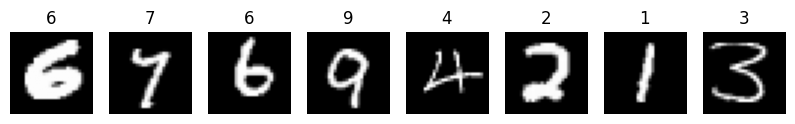

In [5]:
# xem thông tin data

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

#1 shape
x0, y0 = train_dataset[0]
print("\nSample shape:", x0.shape)
print("Label:", y0)

# value range
print("\nPixel min:", x0.min().item())
print("Pixel max:", x0.max().item())

# phân bố label
from collections import Counter

train_labels = [train_dataset[i][1] for i in range(1000)]
label_count = Counter(train_labels)

print("\nLabel distribution (first 1000 samples):")
for k in sorted(label_count.keys()):
    print(f"{k}: {label_count[k]}")

# visualize 8 ảnh đầu
fig, ax = plt.subplots(1, 8, figsize=(10,2))

for i in range(8):
    img, label = train_dataset[i]
    ax[i].imshow(img.squeeze(), cmap="gray")
    ax[i].set_title(str(label))
    ax[i].axis("off")

plt.show()

In [6]:
pin_memory = True  
NUM_WORKERS = 2     

train_loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    generator=train_loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("Batch size:", BATCH_SIZE)
print("Num workers:", NUM_WORKERS)
print("Pin memory:", pin_memory)

Batch size: 64
Num workers: 2
Pin memory: True


In [7]:
#check lại
print("GPU available:", torch.cuda.is_available())
print("Device:", device)

GPU available: True
Device: cuda



Batch 1
x shape: torch.Size([64, 1, 28, 28])
y sample: tensor([7, 4, 3, 5, 7, 5, 5, 6, 1, 5])
min: -0.4242129623889923 max: 2.821486711502075


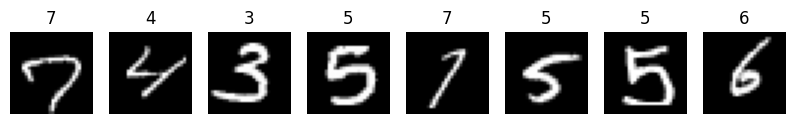


Batch 2
x shape: torch.Size([64, 1, 28, 28])
y sample: tensor([6, 1, 9, 9, 5, 8, 4, 1, 9, 9])
min: -0.4242129623889923 max: 2.821486711502075


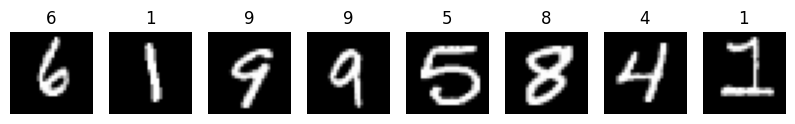

In [8]:
# xem 2 batch đầu
def check_batches_dau(loader, n_batches=2):
    it = iter(loader)

    for i in range(n_batches):
        x, y = next(it)

        print(f"\nBatch {i+1}")
        print("x shape:", x.shape)
        print("y sample:", y[:10])

        print("min:", x.min().item(), "max:", x.max().item())

        fig, ax = plt.subplots(1, 8, figsize=(10,2))

        for j in range(8):
            ax[j].imshow(x[j].cpu().squeeze(), cmap="gray")
            ax[j].set_title(str(y[j].item()))
            ax[j].axis("off")

        plt.show()

check_batches_dau(train_loader, n_batches=2)

In [9]:
# model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

model = MLP().to(device)

print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu1): ReLU()
  (relu2): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
)


In [10]:
#loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

print(criterion)
print(optimizer)

CrossEntropyLoss()
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [11]:
# train model
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_epoch = 0
best_state_dict = None

for epoch in range(1, EPOCHS + 1):
    
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()

            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    # lưu lại
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    updated = False
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state_dict = model.state_dict()
        updated = True

    print(f"Epoch [{epoch}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    if updated:
        print("  -> Da cap nhat best_state_dict theo validation accuracy.")

print("\n==============================")
print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print("==============================")

Epoch [1/20] | Train Loss: 2.1482 | Train Acc: 36.84% | Val Loss: 1.9257 | Val Acc: 67.32%
  -> Da cap nhat best_state_dict theo validation accuracy.
Epoch [2/20] | Train Loss: 1.6274 | Train Acc: 66.42% | Val Loss: 1.2311 | Val Acc: 78.93%
  -> Da cap nhat best_state_dict theo validation accuracy.
Epoch [3/20] | Train Loss: 1.0321 | Train Acc: 76.64% | Val Loss: 0.7736 | Val Acc: 84.07%
  -> Da cap nhat best_state_dict theo validation accuracy.
Epoch [4/20] | Train Loss: 0.7408 | Train Acc: 81.09% | Val Loss: 0.5905 | Val Acc: 85.77%
  -> Da cap nhat best_state_dict theo validation accuracy.
Epoch [5/20] | Train Loss: 0.6142 | Train Acc: 82.89% | Val Loss: 0.5033 | Val Acc: 86.97%
  -> Da cap nhat best_state_dict theo validation accuracy.
Epoch [6/20] | Train Loss: 0.5431 | Train Acc: 84.71% | Val Loss: 0.4529 | Val Acc: 87.78%
  -> Da cap nhat best_state_dict theo validation accuracy.
Epoch [7/20] | Train Loss: 0.4975 | Train Acc: 85.64% | Val Loss: 0.4189 | Val Acc: 88.52%
  -> Da c

In [12]:
# test
model.load_state_dict(best_state_dict)
model.to(device)
model.eval()

test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct / total * 100
test_loss = test_loss / len(test_loader)

print("==============================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("==============================")

Test Loss: 0.2597
Test Accuracy: 92.47%


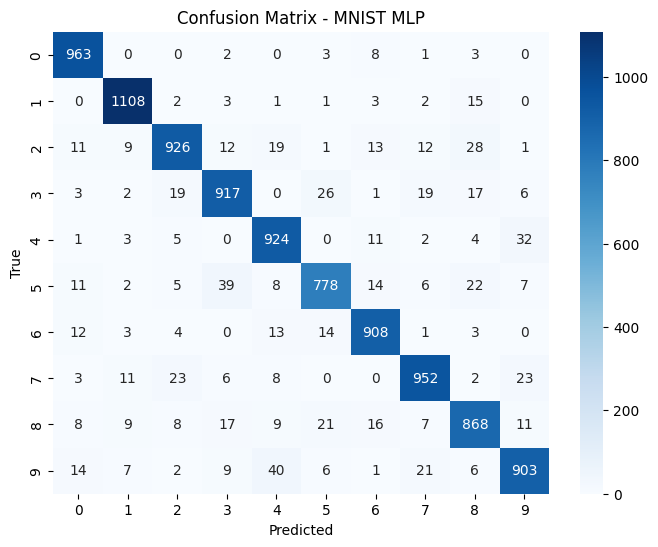

In [13]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - MNIST MLP")
plt.show()

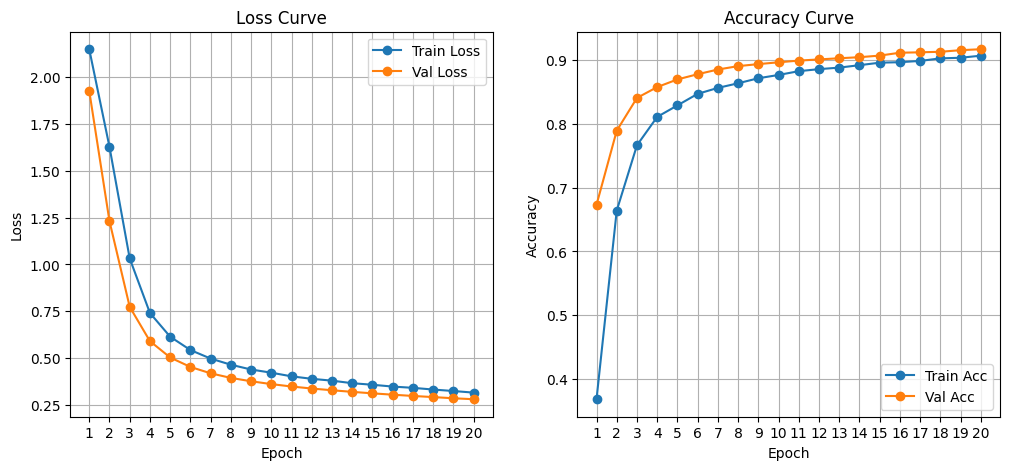

In [14]:
# loss + accuracy
epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='o')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(np.arange(1, 21, 1))
plt.legend()
plt.grid()

# acc
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Acc', marker='o')
plt.plot(epochs, val_accs, label='Val Acc', marker='o')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, 21, 1))
plt.legend()
plt.grid()

plt.show()

In [15]:
print(epochs)
print(type(epochs[0]))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
<class 'int'>


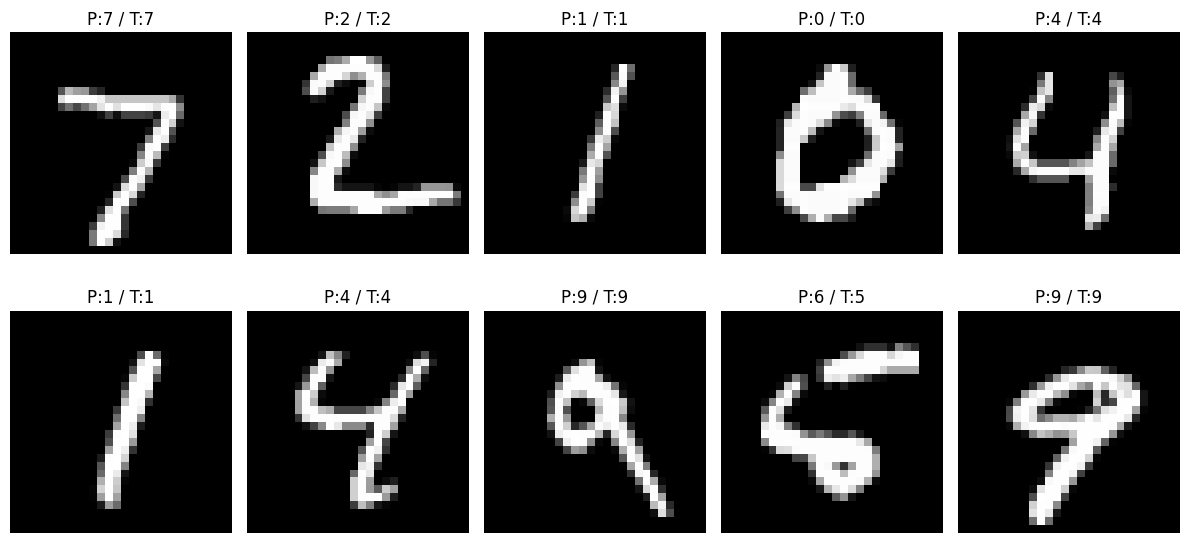

In [17]:
examples = iter(test_loader)
images, labels = next(examples)

images_flat = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    outputs = model(images_flat)
    _, preds = torch.max(outputs, 1)

images = images.numpy()

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"P:{preds[i].item()} / T:{labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
torch.save(best_state_dict, "mnist_mlp_best.pth")

In [22]:
MODEL_PATH = "./output/models/mnist_mlp_best.pth"

torch.save(best_state_dict, MODEL_PATH)

print("Saved model to:", MODEL_PATH)

Saved model to: ./output/models/mnist_mlp_best.pth
